In [1]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/AI/1CWK100/')

In [3]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

# Task 1




## Basic structure

Please use the structure below as your starting point. Once you are up and running then you are free to adjust it, but try to stick to the following basic approach: i) divide your investigation up into smaller code cells; ii) have text cells above each code cell briefly describing what is happening in the code, along with any relevant findings it produces.

Relatively quickly, you should be able to reuse some code from the labs to prepare the assignment dataset and evaluate at least one model with a basic holdout recipe. This would get you a pass. Ask for help if you're struggling, and read the later sections once you're ready to start aiming for higher marks. Good luck!

## Dataset preparation
Example text: The following code prepares the data using a simple 60/40 holdout approach with shuffling.

Data Cleaning - Missing Values not relevant 584 not null values
              - Duplicate Values reduced from 584 to 583

              - Irrelevant features- using a correlation matrix and seaborn package decided to remove patient_id as it is just an identifier

              - Errors in Categorial Data possible typo np changed to no

              - Errors in Numerical Data negative feature value for 6th and 7th numerical feature ( Max_Consolidation_width + Max_Consolidation_height) , i added a box plot to demonstrate the outlier and another after it had been removed
              
              - Added stratified sampling to make the class balanced


4.28

<class 'pandas.core.frame.DataFrame'>
Index: 583 entries, 0 to 583
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_Age               583 non-null    int64  
 1   Male                      583 non-null    float64
 2   Xray_Brightness           583 non-null    float64
 3   Xray_Contrast             583 non-null    float64
 4   Silhouette_Sign           583 non-null    int64  
 5   Max_Consolidation_Width   583 non-null    int64  
 6   Max_Consolidation_Height  583 non-null    int64  
 7   Cavity_Presence           583 non-null    float64
 8   Fluid_Level               583 non-null    float64
 9   Air_Bronchograms          583 non-null    float64
 10  Pneumonia                 583 non-null    object 
dtypes: float64(6), int64(4), object(1)
memory usage: 54.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 583 entries, 0 to 583
Data columns (total 11 columns):
 #   Column      

/tmp/ipython-input-1096222660.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observations['Pneumonia'] = observations['Pneumonia'].replace({'yes': 1, 'no': 0})


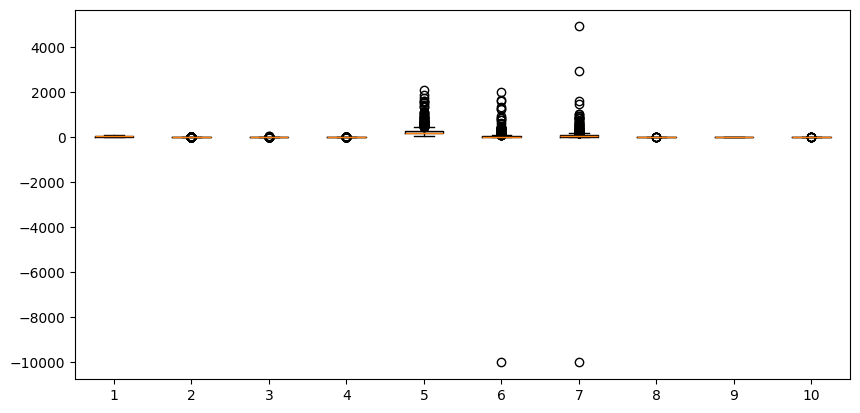

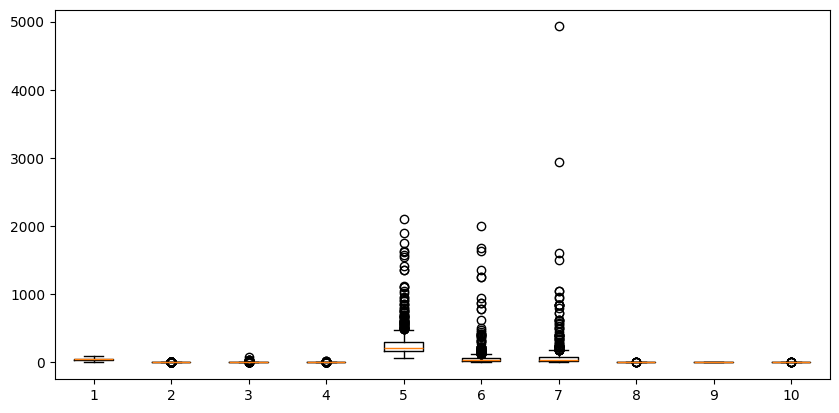

In [4]:
# data preparation steps

# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')
#print(observations.head())

#Data Cleaning
# Duplicate Value
observations = observations.drop_duplicates()
# Irrelevant features
observations = observations.drop(columns='Patient_ID')
print(observations.info())
#Error in categorical data typo in Pneumonia column np should be no
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')
#Convert Pneumonnia column string from yes/no to 1 and 0
observations['Pneumonia'] = observations['Pneumonia'].replace({'yes': 1, 'no': 0})
print(observations.info())

import matplotlib.pyplot as plt

examples = observations.drop(columns='Pneumonia')

# Set the figure size
plt.figure(figsize=(10, 4.8))

# Create the boxplot to show any outliers
plt.boxplot(examples)
plt.show()

observations = observations[
    (observations['Max_Consolidation_Width'] >= 0) &
    (observations['Max_Consolidation_Height'] >= 0)]

examples = observations.drop(columns='Pneumonia')

# Set the figure size
plt.figure(figsize=(10, 4.8))

# Box plot after removing outlier
plt.boxplot(examples)
plt.show()




# Set the name of the target feature
target_feature = 'Pneumonia'

# Load all the observations from file
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    # Stratified Sampling
    stratify=labels
)
# Creating a new StandardScaler to prevent double scaling and use when nessessary
#scaler = StandardScaler()
#train_scaled = scaler.fit_transform(train_examples)
#test_scaled = scaler.transform(train_examples)

# Justification on General Recipe Changes

**K fold Cross validation**

Instead of relying on a single train/test split, k fold cross validation was used. With a small dataset, performance is heavily based on how the data is split with some example/label pairs being used more/less in the train of models, k-Fold cross validation makes sure every pair is equally important by evaluating the model across 5 splits

**Pipeline**

When i had added the K fold approach we had to loop over the indicies manually, perform corss validation and applying the standardisation transformation. However as that was alot of repeated work i decided to use pipelines instead to combine the data processing steps with supervised learning models avoiding leakage. It also made the modelling process cleaner and easier to use

**Using A better performance metrix** - f1 and accuracy

Accuracy alone did not represent my model performance especially when my dataset was imbalanced. Commonly models have achieve a high accuracy whilst failing to correctly identify disease cases.

For this reason, the F1 score was used alongside accuracy. The f1 score balances precision and recall which made it more suitable to evaluating disease. Using both metrics provides me with a clearer and a more balanced assessment of model performance

**Dictionary List**

Hyperparameters were stored using dictionaries rather than seperate lists for each result. This made is easier to run a nested loop and test against 2 hyperparameters. It also improves reproductability and was vital in being able to print the best results.

**Data Cleaning**

Prior to model training, several data cleaning steps were applied to avoid introducing bias or noise into the models
Missing Values: This was not a concern as all relevant features contained 584 non null values

Duplicate Value: Only 1 duplicate record was identified, reducing the dataset from 584 to 583. Removing it ensures that no observation is over-represented

Irrelevant Features: The feature patient_id was removed after i had used a correlation matrix and seaborn visualisation and was found to have no relevance

Errors in Categorical Data: Minor inconsistencies were found, such as a typo where "np" was used instead of "no". This was adjusted to reflect the true category preventing the model from interpretting them as separate categories.

Errors in Numerical Data: Negative value was identified using box plots in two features Max_consolidation_width and Max_consolidation_height.
Since negative values are not possible they were treated as errors. This prevents models from learning from invalid data.

**Stratified Sampling**

Stratified sampling was used when splitting the dataset into training and and test sets
Because of the limitied dataset and class imbalance, a regular "train_test_split()"  could result in under-representation of one class. This would make evaluation metrics unreliable.

By using Stratified Sampling both classes are prportionally represented and minimizes the risk of high or low accuracy due to class imblanace.



## Model 1 evaluation - Decision Tree
The following code cell evaluates a Decision Tree model. I utilised two hyperparameters Max_depth and Min_samples_split within a nested for loop

The Hyperparameter max_depth was tested with a range from 5 to 101, by limitting the depth we prevented overfitting and ensures it focuses on broader and more reliable patterns

The second hyperparameter used was min_sample_values from 5 to 101, this forces the model to only create a new branch if it is supported by a number of patient samples

The best accuracy found was 0.6596 with a max depth of 20, min_samples_split of 5

The best f1 macro found was 0.5977 with a max depth of 20, min_samples_split of 5

In [5]:
# Evaluating Decision Tree
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt


# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Define the range of hyperparameter values we're interested in
max_depth_values = list(range(5, 101, 5))
min_samples_values = list(range(5, 101, 5))
# Dictionary list to hold the resulting accuracies
results = {}
for max_depth in max_depth_values:
  results[str(max_depth)] = {'f1': [], 'accuracy': []}

#Variable to track best performing accuracies
best_f1 = 0
best_f1_params = None
best_acc = 0
best_acc_params = None

**Nested For Loop Testing Performance of Min_Samples_Split and Max_Depth**

This code cell runs a nested loop to run two hyperparameters, with a 5 split k and two cross_val_scores 1 for accuracy and 1 for f1 macro to compare performance consistently

In [6]:
#Nested for loop for evaluate multiple hyperparameters
for max_depth in max_depth_values:
  for min_samples_split in min_samples_values:
    # Create a decision tree classifier model object
    model = DecisionTreeClassifier(max_depth=max_depth,min_samples_split=min_samples_split,random_state=99)
    # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    f1_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
    mean_f1 = np.mean(f1_fold)
    results[str(max_depth)]['f1'].append(mean_f1)
    #For loop to run until highest f1 is found
    if mean_f1 > best_f1:
      best_f1 = mean_f1
      best_f1_details = {'max_depth': max_depth, 'min_samples_split': min_samples_split, 'f1': mean_f1}

    # calculate the f1 metric scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    accuracy_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
    mean_accuracy = np.mean(accuracy_fold)
    results[str(max_depth)]['accuracy'].append(mean_accuracy)
    #For loop to run until highest accuracy is found
    if mean_accuracy > best_acc:
      best_acc = mean_accuracy
      best_acc_details = {'max_depth': max_depth, 'min_samples_split': min_samples_split, 'accuracy': mean_accuracy}
    #Print every result
    print(f"tree depth={max_depth}: min_samples_split={min_samples_split} F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")



tree depth=5: min_samples_split=5 F1-Macro=0.5111 | Accuracy=0.6445
tree depth=5: min_samples_split=10 F1-Macro=0.5081 | Accuracy=0.6402
tree depth=5: min_samples_split=15 F1-Macro=0.5008 | Accuracy=0.6337
tree depth=5: min_samples_split=20 F1-Macro=0.4993 | Accuracy=0.6316
tree depth=5: min_samples_split=25 F1-Macro=0.5054 | Accuracy=0.6403
tree depth=5: min_samples_split=30 F1-Macro=0.5023 | Accuracy=0.6424
tree depth=5: min_samples_split=35 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=40 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=45 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=50 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=55 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=60 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=65 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=70 F1-Macro=0.5036 | Accuracy=0.6424
tree depth=5: min_samples_split=75 

This code cell shows the Best accuracies and f1 macro for Decision tree with 2 hyperparameters, also shows the corresponding depth and split values

In [7]:
print(f"Best Accuracy: {best_acc_details['accuracy']:.4f}, "
      f"max_depth: {best_acc_details['max_depth']}, "
      f"min_samples_split: {best_acc_details['min_samples_split']}")

print(f"Best F1 macro: {best_f1_details['f1']:.4f}, "
      f"max_depth: {best_f1_details['max_depth']}, "
      f"min_samples_split: {best_f1_details['min_samples_split']}")

Best Accuracy: 0.6596, max_depth: 20, min_samples_split: 5
Best F1 macro: 0.5977, max_depth: 20, min_samples_split: 5


Graph Below

In [10]:
plt.figure(figsize=(10, 6))
# Accuracy
plt.plot(tree_depths, mean_accuracies, marker='o', linestyle='--', color='blue', label='Accuracy')
# F1-Macro
plt.plot(tree_depths, mean_f1_score, marker='o', linestyle='-', color='red', label='F1-Macro')

plt.title('Decision Tree Performance: Accuracy vs. F1-Macro')
plt.xlabel('Tree Depth')
plt.ylabel('Score')
plt.xticks(tree_depths)
plt.legend()
plt.grid(True)
plt.show()

# Train a final model with a chosen hyperparameter
# Based on the output, tree_depth=5 gave F1-Macro=0.5977 and Accuracy=0.6596.
final_decision_tree_model = DecisionTreeClassifier(min_samples_split=5, random_state=99)
final_decision_tree_model.fit(non_test_examples, non_test_labels)

y_pred = final_decision_tree_model.predict(test_examples)
y_true = test_labels

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

NameError: name 'tree_depths' is not defined

<Figure size 1000x600 with 0 Axes>

## Model 2 evaluation - k-Nearest Neighbours model
The following code cell evaluates a k-Nearest Neighbours model. I utilised two hyperparameters k_values and weights within a nested for loop

The Hyperparameter k_values was tested with a range from 1 to 21, as it is the primary tool for balancing Bias-Variance tradeoff. The range allowed me to find the optimal neighborhood size. It is important to note My best f1 macro found did used a n=1 which is overly sensitive to noise and outlier with it being a small k

The second hyperparameter weights was tested with both weighing scheme to determine how proximity of neighbors should influence the classification. With uniform setting producing better results showing local density is a more reliable predictor

The Best Accuracy found was 0.7091, Weight: uniform, N_Neighbor: 19


The Best F1 macro was 0.6135, Weight: uniform, N_Neighbor: 1

In [9]:
# Evaluating K-Nearest Neighbours
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Define the range of k (number of neighbors) values and Weights to test
k_values = list(range(1, 21, 2)) # Test odd k values from 1 to 19
weights = ['uniform', 'distance']

# List to hold the resulting accuracies
results = {
    'uniform': {'f1' : [], 'accuracy': []},
    'distance': {'f1' : [], 'accuracy': []}
}
# Variable to track best performing accuracies
best_f1 = 0
best_f1_params = None
best_acc = 0
best_acc_params = None

**Testing Performance of KNN with two hyperparameters N_neighbors and Weights to find best accuracy and F1 Metic**

This code cell runs a nested loop to run two hyperparameters, with a 5 split k and two cross_val_scores 1 for accuracy and 1 for f1 macro to compare performance consistently

In [11]:
# Nested for loop for Testing multiple hyperparameters
for w in weights:
  for k in k_values:
    # Create a pipeline combining model with preprocessing step
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=k, weights=w))])

    # Calculating f1 Macro scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    f1_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
    mean_f1 = np.mean(f1_fold)
    results[w]['f1'].append(mean_f1)
    # For loop to run until highest f1 is found
    if mean_f1 > best_f1:
      best_f1 = mean_f1
      best_f1_details = {'w': w, 'k': k, 'f1': mean_f1}


    # Calculating accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    accuracy_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
    mean_accuracy = np.mean(accuracy_fold)
    results[w]['accuracy'].append(mean_accuracy)
     # For loop to run until highest accuracy is found
    if mean_accuracy > best_acc:
      best_acc = mean_accuracy
      best_acc_details = {'w': w, 'k': k, 'accuracy': mean_accuracy}
    # Prints every result
    print(f"k={k}, w={w}: F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")


k=1, w=uniform: F1-Macro=0.6135 | Accuracy=0.6748
k=3, w=uniform: F1-Macro=0.5333 | Accuracy=0.6272
k=5, w=uniform: F1-Macro=0.5105 | Accuracy=0.6272
k=7, w=uniform: F1-Macro=0.4997 | Accuracy=0.6294
k=9, w=uniform: F1-Macro=0.5145 | Accuracy=0.6551
k=11, w=uniform: F1-Macro=0.5221 | Accuracy=0.6681
k=13, w=uniform: F1-Macro=0.5293 | Accuracy=0.6767
k=15, w=uniform: F1-Macro=0.5280 | Accuracy=0.6789
k=17, w=uniform: F1-Macro=0.5592 | Accuracy=0.7090
k=19, w=uniform: F1-Macro=0.5515 | Accuracy=0.7091
k=1, w=distance: F1-Macro=0.6135 | Accuracy=0.6748
k=3, w=distance: F1-Macro=0.5451 | Accuracy=0.6337
k=5, w=distance: F1-Macro=0.5330 | Accuracy=0.6401
k=7, w=distance: F1-Macro=0.5363 | Accuracy=0.6531
k=9, w=distance: F1-Macro=0.5556 | Accuracy=0.6767
k=11, w=distance: F1-Macro=0.5477 | Accuracy=0.6789
k=13, w=distance: F1-Macro=0.5413 | Accuracy=0.6768
k=15, w=distance: F1-Macro=0.5590 | Accuracy=0.6918
k=17, w=distance: F1-Macro=0.5546 | Accuracy=0.6940
k=19, w=distance: F1-Macro=0.544

Best accuracies and f1 metrics

In [12]:
# Print best accuracy along with corresponding Weight and k number of neighbor
print(f"Best Accuracy: {best_acc_details['accuracy']:.4f}, "
      f"Weight: {best_acc_details['w']}, "
      f"N_Neighbor: {best_acc_details['k']}")

# Print best f1 metric along with corresponding Weight and k number of neighbor
print(f"Best F1 macro: {best_f1_details['f1']:.4f}, "
      f"Weight: {best_f1_details['w']}, "
      f"N_Neighbor: {best_f1_details['k']}")

Best Accuracy: 0.7091, Weight: uniform, N_Neighbor: 19
Best F1 macro: 0.6135, Weight: uniform, N_Neighbor: 1


Graph Below

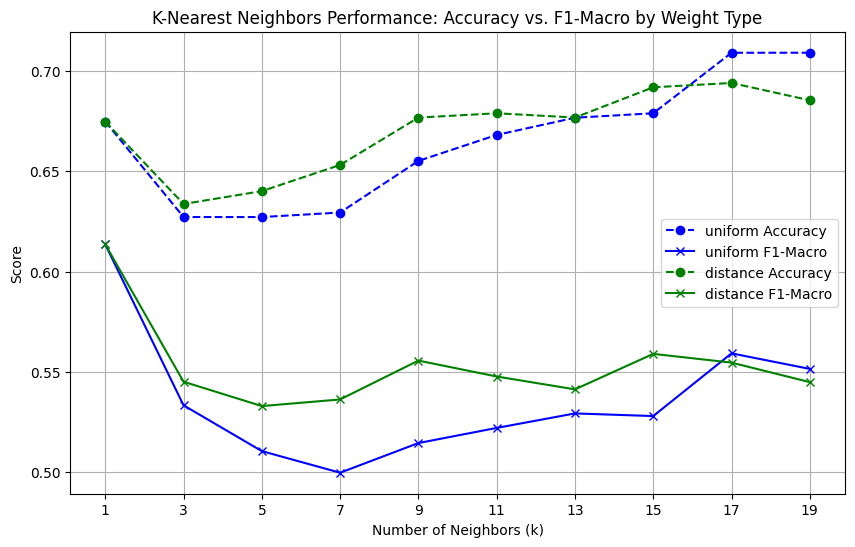

In [13]:

plt.figure(figsize=(10, 6))
colors = {'uniform': 'blue', 'distance': 'green'}
f1_label_suffix = " (F1-Macro)"
acc_label_suffix = " (Accuracy)"

for w in weights:
    # Plot Accuracy
    plt.plot(k_values, results[w]['accuracy'], marker='o', linestyle='--', color=colors[w], label=f'{w} Accuracy')
    # Plot F1-Macro
    plt.plot(k_values, results[w]['f1'], marker='x', linestyle='-', color=colors[w], label=f'{w} F1-Macro')

plt.title('K-Nearest Neighbors Performance: Accuracy vs. F1-Macro by Weight Type')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

## Model 3 evaluation - Random forest
The following code cell evaluates a Random forest model.Two key hyperparameters, n_estimators and max_depth_values within a nested for loop to assess their impact on model performance

The Hyperparameter n_estimators (number of trees) was tested with a range from 5 to 250 to indentify a balance between model stability and computational cost. Increase the number of trees helps reduce variance compared to a single decision tree.

The second hyperparameter maximum tree depth ( max_depth) was tested with a range of 5 to 101 to control model complexity and reduce overfitting. Shallow trees encourage better generalisation but deeper trees also complex patterns to be caught


The Best Accuracy was 0.6963, max_depth: 5, n_estimators: 55


The Best F1 macro was 0.5997, max_depth: 25, n_estimators: 30


By using both metrics it accounts for potential class imblance.

In [14]:
# Evaluating Random forest
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt


# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Define the range of hyperparameter values we're intrested in
n_estimators = list(range(5,250,25))
max_depth_values = list(range(5, 101, 20))

#Dictionary list to hold the resulting accuracies
results = {}
for n in n_estimators:
  results[str(n)] = {'f1': [], 'accuracy': []}

#Variable to track best performing accuracies
best_f1 = 0
best_f1_params = None
best_acc = 0
best_acc_params = None


In [15]:
# Nested for loop for multiple hyperparameters
for n in n_estimators:
  for max_depth in max_depth_values:
    # Create a Random forest classifier model object
    model = RandomForestClassifier(n_estimators=n, max_depth=max_depth, random_state=99)
    # calculate the f1 scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    f1_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
    mean_f1 = np.mean(f1_fold)
    results[str(n)]['f1'].append(mean_f1)
    # For loop to run until highest f1 is found
    if mean_f1 > best_f1:
      best_f1 = mean_f1
      best_f1_details = {'n_estimators': n, 'max_depth': max_depth, 'f1': mean_f1}

    # calculate the accuracies scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    accuracy_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
    mean_accuracy = np.mean(accuracy_fold)
    results[str(n)]['accuracy'].append(mean_accuracy)
    # For loop to run until highest accuracy is found
    if mean_accuracy > best_acc:
      best_acc = mean_accuracy
      best_acc_details = {'n_estimators': n, 'max_depth': max_depth, 'accuracy': mean_accuracy}
    # Print every result
    print(f"Trees={n}: Depth={max_depth} F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")

Trees=5: Depth=5 F1-Macro=0.5852 | Accuracy=0.6962
Trees=5: Depth=25 F1-Macro=0.5887 | Accuracy=0.6790
Trees=5: Depth=45 F1-Macro=0.5887 | Accuracy=0.6790
Trees=5: Depth=65 F1-Macro=0.5887 | Accuracy=0.6790
Trees=5: Depth=85 F1-Macro=0.5887 | Accuracy=0.6790
Trees=30: Depth=5 F1-Macro=0.5466 | Accuracy=0.6898
Trees=30: Depth=25 F1-Macro=0.5997 | Accuracy=0.6962
Trees=30: Depth=45 F1-Macro=0.5997 | Accuracy=0.6962
Trees=30: Depth=65 F1-Macro=0.5997 | Accuracy=0.6962
Trees=30: Depth=85 F1-Macro=0.5997 | Accuracy=0.6962
Trees=55: Depth=5 F1-Macro=0.5574 | Accuracy=0.6963
Trees=55: Depth=25 F1-Macro=0.5758 | Accuracy=0.6855
Trees=55: Depth=45 F1-Macro=0.5758 | Accuracy=0.6855
Trees=55: Depth=65 F1-Macro=0.5758 | Accuracy=0.6855
Trees=55: Depth=85 F1-Macro=0.5758 | Accuracy=0.6855
Trees=80: Depth=5 F1-Macro=0.5496 | Accuracy=0.6898
Trees=80: Depth=25 F1-Macro=0.5894 | Accuracy=0.6941
Trees=80: Depth=45 F1-Macro=0.5894 | Accuracy=0.6941
Trees=80: Depth=65 F1-Macro=0.5894 | Accuracy=0.6941
Tr

Best Accuracy: 0.6963, max_depth: 5, n_estimators: 55
Best F1 macro: 0.5997, max_depth: 25, n_estimators: 30

In [16]:
print(f"Best Accuracy: {best_acc_details['accuracy']:.4f}, "
      f"max_depth: {best_acc_details['max_depth']}, "
      f"n_estimators: {best_acc_details['n_estimators']}")

print(f"Best F1 macro: {best_f1_details['f1']:.4f}, "
      f"max_depth: {best_f1_details['max_depth']}, "
      f"n_estimators: {best_f1_details['n_estimators']}")

Best Accuracy: 0.6963, max_depth: 5, n_estimators: 55
Best F1 macro: 0.5997, max_depth: 25, n_estimators: 30


Graph Below

In [18]:
plt.figure(figsize=(10, 6))
# Plot Accuracy
plt.plot(n_estimators, mean_accuracies, marker='o', linestyle='--', color='blue', label='Accuracy')
# Plot F1-Macro
plt.plot(n_estimators, mean_f1_score, marker='o', linestyle='-', color='red', label='F1-Macro')

plt.title('Random forest Performance: Accuracy vs. F1-Macro')
plt.xlabel('Number of decision trees to train')
plt.ylabel('Score')
plt.xticks(n_estimators)
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'mean_accuracies' is not defined

<Figure size 1000x600 with 0 Axes>

## Model 4 evaluation - Naive Bayes

The following code cell evaluates a Naive Bayes model. The resulting accuracy is 0.5475 and the F1 macro is 0.5473.

No hyperparameter tuning was applied, as Gaussian has limited tunable parameters and is commonly only used as a baseline.


In [19]:
# Evaluating Naive Bayes
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt



# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = GaussianNB()
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
f1_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
mean_f1 = np.mean(f1_fold)


accuracy_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
mean_accuracy = np.mean(accuracy_fold)
print(f"Naive Bayes F1-Macro = {mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")

Naive Bayes F1-Macro = 0.5473 | Accuracy=0.5475


## Model 5 evaluation - Logistic regression
The following code cell evaluates a Logistic Regression model. Two hyperparameters max_iter and penalty were explored using a nested for loop to identify the best performance.

The max_iter hyperparameter was tested with a range of 5 to 1000 to ensure it had sufficient iteration to converge, while also checking is early convergence was a valid tune for this dataset

The penalty parameter was tested using L1,L2 and ElasticNet regularisation. Regularisation was explored to control overfitting and assess where sparsity (L1) or weight shrinkage (L2) was more suitable.

The Best Accuracy was  0.7350, max_iter: 5, penalty: l1
The Best F1 macro was 0.6484, max_iter: 5, penalty: l1

This suggest that a sparsity was beneficial for  this dataset and that the model converged quickly

In [20]:
# Evaluating Logistic Regression
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))


# Define the range hyperparameter values to test
max_iter_values = [5, 10, 20, 50, 100, 200, 500,700,900,1000]
penalty_values = ['l2','l1','elasticnet']

# List to hold the resulting accuracies
results = {
    'l2': {'f1' : [], 'accuracy': []},
    'l1': {'f1' : [], 'accuracy': []},
    'elasticnet': {'f1' : [], 'accuracy': []}
}

#Variable to track best performing accuracies
best_f1 = 0
best_f1_params = None
best_acc = 0
best_acc_params = None

**Nested For Loop Testing Performance of Max_Iter and Penalty**

In [21]:
# Nested for loop for multiple hyperparameters
for penalty in penalty_values:
  #If statement for 3rd penalty value
  if penalty == 'elasticnet':
      for max_iter in max_iter_values:
        # Create a pipeline combining our model with our preprocessing step
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(max_iter=max_iter, random_state=99, loss='log_loss',penalty='elasticnet', l1_ratio=0.15))])

        # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
        f1_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
        mean_f1 = np.mean(f1_fold)
        results[penalty]['f1'].append(mean_f1)
        #For loop to run until highest f1 is found
        if mean_f1 > best_f1:
          best_f1 = mean_f1
          best_f1_details = {'max_iter': max_iter, 'penalty': penalty, 'f1': mean_f1}

        accuracy_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
        mean_accuracy = np.mean(accuracy_fold)
        results[penalty]['accuracy'].append(mean_accuracy)
        #For loop to run until highest accuracy is found
        if mean_accuracy > best_acc:
          best_acc = mean_accuracy
          best_acc_details = {'max_iter': max_iter, 'penalty': penalty, 'accuracy': mean_accuracy}
        print(f"max_iter={max_iter}: penalty={penalty} F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")

  #Catch for all other penalty values without l1_ratio
  else:
    for max_iter in max_iter_values:
      # Create a pipeline combining our model with our preprocessing step
      pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(max_iter=max_iter, random_state=99, loss='log_loss',penalty=penalty))])

      # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
      f1_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
      mean_f1 = np.mean(f1_fold)
      results[penalty]['f1'].append(mean_f1)
      #For loop to run until highest f1 is found
      if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_f1_details = {'max_iter': max_iter, 'penalty': penalty, 'f1': mean_f1}

      accuracy_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
      mean_accuracy = np.mean(accuracy_fold)
      results[penalty]['accuracy'].append(mean_accuracy)
      #For loop to run until highest accuracy is found
      if mean_accuracy > best_acc:
        best_acc = mean_accuracy
        best_acc_details = {'max_iter': max_iter, 'penalty': penalty, 'accuracy': mean_accuracy}
      print(f"max_iter={max_iter}: penalty={penalty} F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

max_iter=5: penalty=l2 F1-Macro=0.6477 | Accuracy=0.7284
max_iter=10: penalty=l2 F1-Macro=0.5943 | Accuracy=0.6788
max_iter=20: penalty=l2 F1-Macro=0.5726 | Accuracy=0.6919
max_iter=50: penalty=l2 F1-Macro=0.6003 | Accuracy=0.6809
max_iter=100: penalty=l2 F1-Macro=0.5798 | Accuracy=0.6962
max_iter=200: penalty=l2 F1-Macro=0.5798 | Accuracy=0.6962
max_iter=500: penalty=l2 F1-Macro=0.5798 | Accuracy=0.6962
max_iter=700: penalty=l2 F1-Macro=0.5798 | Accuracy=0.6962
max_iter=900: penalty=l2 F1-Macro=0.5798 | Accuracy=0.6962
max_iter=1000: penalty=l2 F1-Macro=0.5798 | Accuracy=0.6962
max_iter=5: penalty=l1 F1-Macro=0.6484 | Accuracy=0.7350
max_iter=10: penalty=l1 F1-Macro=0.5573 | Accuracy=0.6681
max_iter=20: penalty=l1 F1-Macro=0.5446 | Accuracy=0.6854
max_iter=50: penalty=l1 F1-Macro=0.6060 | Accuracy=0.7049


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

max_iter=100: penalty=l1 F1-Macro=0.5994 | Accuracy=0.7049
max_iter=200: penalty=l1 F1-Macro=0.5994 | Accuracy=0.7049
max_iter=500: penalty=l1 F1-Macro=0.5994 | Accuracy=0.7049
max_iter=700: penalty=l1 F1-Macro=0.5994 | Accuracy=0.7049
max_iter=900: penalty=l1 F1-Macro=0.5994 | Accuracy=0.7049
max_iter=1000: penalty=l1 F1-Macro=0.5994 | Accuracy=0.7049
max_iter=5: penalty=elasticnet F1-Macro=0.6335 | Accuracy=0.7177
max_iter=10: penalty=elasticnet F1-Macro=0.5999 | Accuracy=0.6767
max_iter=20: penalty=elasticnet F1-Macro=0.5638 | Accuracy=0.6940


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

max_iter=50: penalty=elasticnet F1-Macro=0.5405 | Accuracy=0.6704
max_iter=100: penalty=elasticnet F1-Macro=0.5444 | Accuracy=0.6639
max_iter=200: penalty=elasticnet F1-Macro=0.5444 | Accuracy=0.6639
max_iter=500: penalty=elasticnet F1-Macro=0.5444 | Accuracy=0.6639
max_iter=700: penalty=elasticnet F1-Macro=0.5444 | Accuracy=0.6639
max_iter=900: penalty=elasticnet F1-Macro=0.5444 | Accuracy=0.6639
max_iter=1000: penalty=elasticnet F1-Macro=0.5444 | Accuracy=0.6639


Best Accuracy: 0.7350, max_iter: 5, penalty: l1
Best F1 macro: 0.6484, max_iter: 5, penalty: l1

In [22]:
print(f"Best Accuracy: {best_acc_details['accuracy']:.4f}, "
      f"max_iter: {best_acc_details['max_iter']}, "
      f"penalty: {best_acc_details['penalty']}")

print(f"Best F1 macro: {best_f1_details['f1']:.4f}, "
      f"max_iter: {best_f1_details['max_iter']}, "
      f"penalty: {best_f1_details['penalty']}")

Best Accuracy: 0.7350, max_iter: 5, penalty: l1
Best F1 macro: 0.6484, max_iter: 5, penalty: l1


Graph Below

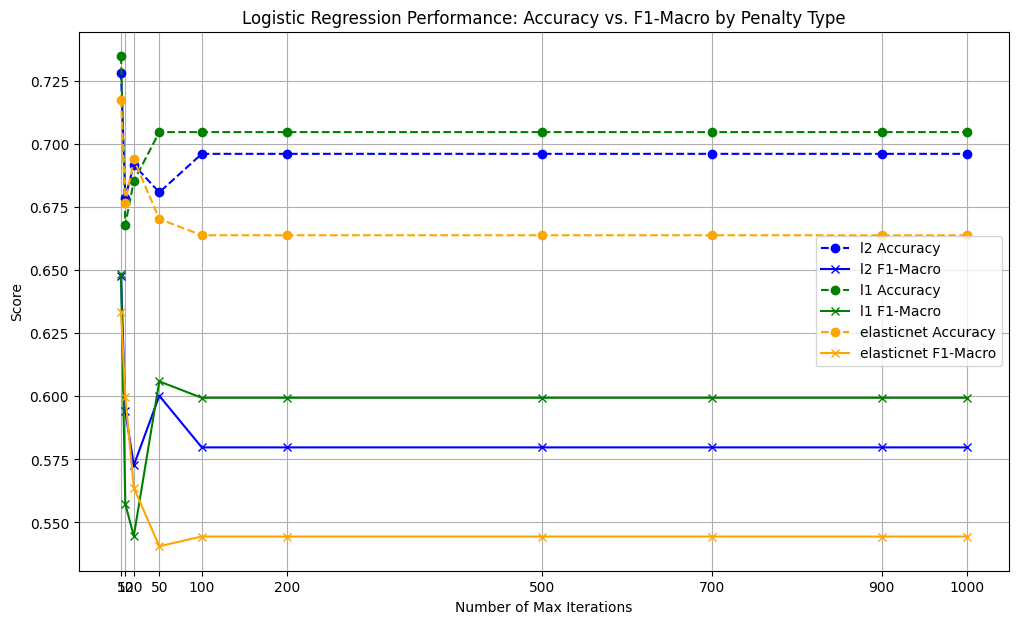

In [23]:
plt.figure(figsize=(12, 7))
colors = {'l2': 'blue', 'l1': 'green', 'elasticnet': 'orange'}
f1_label_suffix = " (F1-Macro)"
acc_label_suffix = " (Accuracy)"

for penalty in penalty_values:
    # Plot Accuracy
    plt.plot(max_iter_values, results[penalty]['accuracy'], marker='o', linestyle='--', color=colors[penalty], label=f'{penalty} Accuracy')
    # Plot F1-Macro
    plt.plot(max_iter_values, results[penalty]['f1'], marker='x', linestyle='-', color=colors[penalty], label=f'{penalty} F1-Macro')

plt.title('Logistic Regression Performance: Accuracy vs. F1-Macro by Penalty Type')
plt.xlabel('Number of Max Iterations')
plt.ylabel('Score')
plt.xticks(max_iter_values)
plt.legend()
plt.grid(True)
plt.show()

## Model 6 evaluation - Support vector machine
The following code cell evaluates a SVM model. Two key hyperparamets, gamma and c were explored using a nested for loop to recover the best performance

The Hyperparameter gamma was tested with a range of 0.01 to 1. Gamma shows how far the influence of a single training point reaches. Smaller values produce smoother decision boundaries, whilst large values allow the model to capture more complex patterns

The second hyperparameter c was tested with a range of 0.01 to 100. This controls the tradeoff between allowing misclassification and maximising the margin. Although high values would allow the model to fit the training data closely, improving performance it can come at a risk of overfitting.

The Best Accuracy was 0.7242, c: 10, gamma: 0.03
The Best F1 macro was 0.6227, c: 10, gamma: 0.84

This indicates that moderate regularisation was effective with C= 10, while different gamma values influenced the balance between accuracy and class performance.

In [24]:
# Evaluating Support Vector Machine
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Define the range of hyperparameter values we're interested in
gammas_values = [x / 100.0 for x in range(1, 100, 1)]
c_values = [0.01, 0.1, 1, 10, 100]

# Dictionary list to hold the resulting accuracies
results = {}
for c_val in c_values:
    results[str(c_val)] = {'f1': [], 'accuracy': []}


# Variable to track best performing accuracies
best_f1 = 0
best_f1_params = None
best_acc = 0
best_acc_params = None


In [25]:
# Nested for loop for multiple hyperparameters
print("Testing Performance Across Different Gamma and C Values")
for c in c_values:
  for gamma in gammas_values:
    # Create a pipeline combining our model with our preprocessing step
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(gamma=gamma, C=c, random_state=99))])

    # calculate the f1 nmetrics for each of the 5 folds, using k-fold cross validation, and return them in an array
    f1_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
    mean_f1 = np.mean(f1_fold)
    results[str(c)]['f1'].append(mean_f1)
    # For loop to run until highest f1 is found
    if mean_f1 > best_f1:
      best_f1 = mean_f1
      best_f1_details = {'c': c, 'gamma': gamma, 'f1': mean_f1}

    # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
    accuracy_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
    mean_accuracy = np.mean(accuracy_fold)
    results[str(c)]['accuracy'].append(mean_accuracy)
    print(f"C={c}, gamma={gamma:.2f}: F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")
    # For loop to run until highest accuracy is found
    if mean_accuracy > best_acc:
      best_acc = mean_accuracy
      best_acc_details = {'c': c, 'gamma': gamma, 'accuracy': mean_accuracy}

Testing Performance Across Different Gamma and C Values
C=0.01, gamma=0.01: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.02: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.03: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.04: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.05: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.06: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.07: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.08: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.09: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.10: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.11: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.12: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.13: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.14: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.15: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.16: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.17: F1-Macro=0.4164 | Accuracy=0.7134
C=0.01, gamma=0.18: F1-Mac

Best Accuracy: 0.7242, c: 10, gamma: 0.03
Best F1 macro: 0.6227, c: 10, gamma: 0.84


In [26]:
print(f"Best Accuracy: {best_acc_details['accuracy']:.4f}, "
      f"c: {best_acc_details['c']}, "
      f"gamma: {best_acc_details['gamma']}")

print(f"Best F1 macro: {best_f1_details['f1']:.4f}, "
      f"c: {best_f1_details['c']}, "
      f"gamma: {best_f1_details['gamma']}")

Best Accuracy: 0.7242, c: 10, gamma: 0.03
Best F1 macro: 0.6227, c: 10, gamma: 0.84


Graph Below


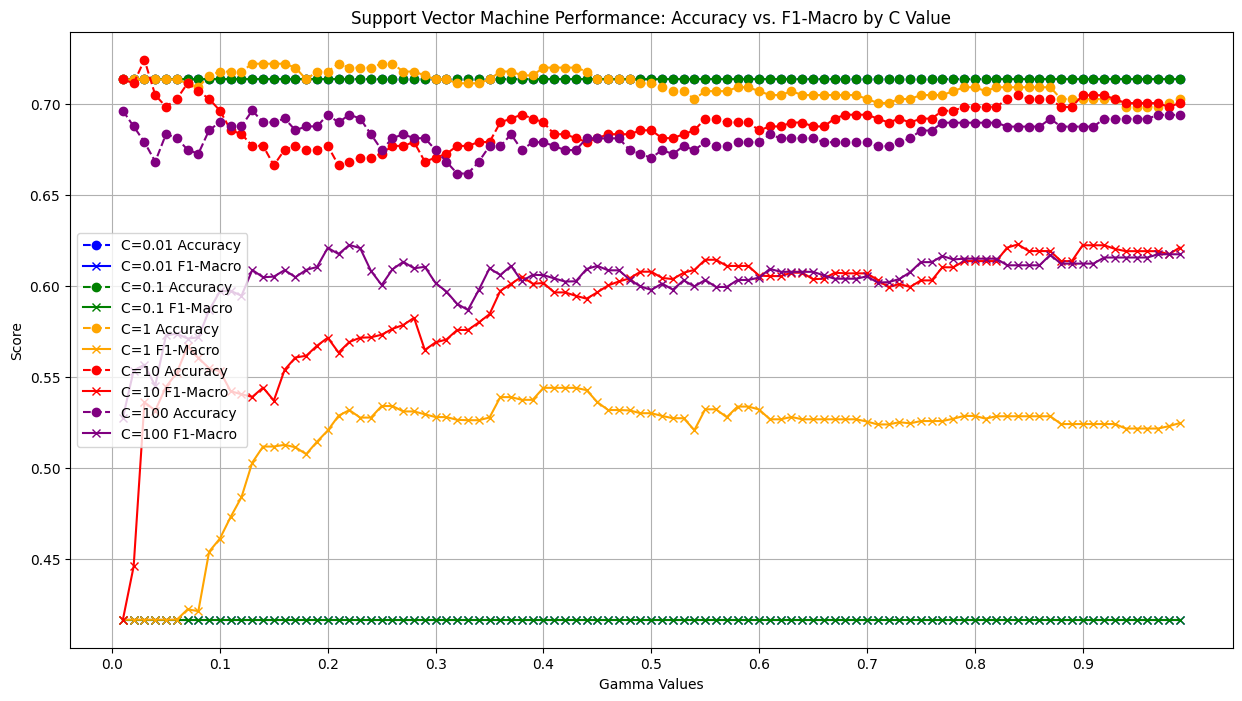

In [27]:
# Plotting results
plt.figure(figsize=(15, 8))

# Define colors for each C value for better visualization
plot_colors = {
    '0.01': 'blue',
    '0.1': 'green',
    '1': 'orange',
    '10': 'red',
    '100': 'purple'
}

for c_str, c_results in results.items():
    # Plot Accuracy
    plt.plot(gammas_values, c_results['accuracy'], marker='o', linestyle='--', color=plot_colors[c_str], label=f'C={c_str} Accuracy')
    # Plot F1-Macro
    plt.plot(gammas_values, c_results['f1'], marker='x', linestyle='-', color=plot_colors[c_str], label=f'C={c_str} F1-Macro')

plt.title('Support Vector Machine Performance: Accuracy vs. F1-Macro by C Value')
plt.xlabel('Gamma Values')
plt.ylabel('Score')
plt.xticks(np.arange(0, 1, 0.1)) # Adjust x-ticks for better visibility
plt.legend()
plt.grid(True)
plt.show()

## Model 7 evaluation - Artificial neural network
The following code cell evaluates a Artifical Neural model. This was tested withthe hyperparameter "layers"

The layers parameter was tested using multiple configuration ranging from a shallow network (100) to deeper networks (50,25,10)

By having different number of layer it allows the model to capture different level of non-linear relationships. Whilst deeper features has its advantages it also increases the risk of overfitting, particularly with smaller datasets

The best accuracy and f1 metric was found at layers=(100, 100):

 F1-Macro=0.6120 | Accuracy=0.6918

 This result suggests that a deep architecture was more effectively able to model  complex feature, more effectively than shallow networks but too many layers reduces the overall performance.


In [29]:
# Evaluate Artificial Neural Network model
#the number and size of hidden layers - argument name: double click to add text
#the maximum number of search steps to take looking for the best model parameters - argument name: hidden_layer_sizes

# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Define the range of hyperparameter values we're interested in
layer_sizes = [(100,), (100, 50), (100, 100), (50, 25, 10)]
mean_accuracies = []
mean_f1_score = []

print("--- Testing Performance Across Different Max Iter Values ---")
for layers in layer_sizes:
  # Create a pipeline combining our model with our preprocessing step
  pipeline = Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes= layers, max_iter= 10000, random_state=99))])

  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  f1_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
  mean_f1 = np.mean(f1_fold)
  mean_f1_score.append(mean_f1)

  accuracy_fold = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
  mean_accuracy = np.mean(accuracy_fold)
  mean_accuracies.append(mean_accuracy)
  print(f"layers={layers}: F1-Macro={mean_f1:.4f} | Accuracy={mean_accuracy:.4f}")


--- Testing Performance Across Different Max Iter Values ---
layers=(100,): F1-Macro=0.5965 | Accuracy=0.6811
layers=(100, 50): F1-Macro=0.6029 | Accuracy=0.6726
layers=(100, 100): F1-Macro=0.6120 | Accuracy=0.6918
layers=(50, 25, 10): F1-Macro=0.6093 | Accuracy=0.6810


# Model 8 evaluation Voting Ensemble

The following code cell evaluated a Voting Ensemble composed of the three strongest models identified - Logistic Regression, K-Nearest Neighbours and Artificial Neural Network.

These models were selected based on their F1-Macro performance, as F1 provides a more reliable evaluation for class imbalance.

Ensembles Design choice - I had originally tried to use hard voting but not all models supported probability estimates ( predict_proba) therefore soft voting was used.

By making this ensemble tune all models it ensures model compatibilit and fairness, with all models having a equal voice.

Best F1 macro: 0.6484, max_iter: 5, penalty: l1, For LOR

Best F1 macro: 0.6135, Weight: uniform, N_Neighbor: 1, For KNN

layers=(100, 100): F1-Macro=0.6120 | Accuracy=0.6918 For ANN



In [28]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))


#BestKNN = KNeighborsClassifier(n_neighbors=1, weights='uniform')
#BestLR = SGDClassifier(max_iter=5, random_state=99, loss='log_loss',penalty='l1')
#BestANN = MLPClassifier(hidden_layer_sizes= (100,100), max_iter= 10000, random_state=99)

# set the details of the classifiers we want to use using their best hyperparameters found in Individual model evaluation all in a pipeline)
KNN_pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=1, weights='uniform'))])
LR_pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(max_iter=5, random_state=99, loss='log_loss',penalty='l1'))])
ANN_pipeline = Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes= (100,100), max_iter= 10000, random_state=99))])


# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
# Create a hard-voting ensemble composed of a k-NN, Logistic Regression and ANN classifier
model = VotingClassifier(estimators=[('knn', KNN_pipeline), ('Logistic Regression', LR_pipeline), ('ANN', ANN_pipeline)], voting='hard')
f1_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
mean_f1 = np.mean(f1_fold)
print(f"Voting Ensemble F1-Macro = {mean_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Voting Ensemble F1-Macro = 0.6374


**Performance Evaluation**

Although the Voting Ensemble achieved improved performance compared to most individual models and against two of the models which composed of the Ensemble, particularly in terms of the f1-macro of 0.6374 indicating better balanced classification. This suggest that aggregating multiple models mitigates individual model weaknesses.

However it did not outperform the best ranking individual model Logistic regression a factor for this is Hard Voting was used which out voted logistic regression when competing against the other 2 individual models.

# Model 10 evaluation Bagging Ensemble

The following code cell evaluates a bagging ensemble composed of a 100 of the best individual model, Logistic Regression. This model was selected due to its F1-Macro performance which ranks the highest of all individual models. I utilised BootStrap ( on by default ) which enable sampling with replacement to investigate is training the model on random subsets of data can reduce variance and improve generalisation.

In [30]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))


#BestKNN = KNeighborsClassifier(n_neighbors=1, weights='uniform')
#BestLR = SGDClassifier(max_iter=5, random_state=99, loss='log_loss',penalty='l1')
#BestANN = MLPClassifier(hidden_layer_sizes= (100,100), max_iter= 10000, random_state=99)

# set the details of the classifiers we want to use using their best hyperparameters found in Individual model evaluation all in a pipeline)
LR_pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(max_iter=5, random_state=99, loss='log_loss',penalty='l1'))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
# Create a hard-voting ensemble composed of a k-NN, Logistic Regression and ANN classifier
# Create a bagging ensemble classifier componsed of 100 DTs
model = BaggingClassifier(LR_pipeline, n_estimators=100, random_state=99)
f1_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
mean_f1 = np.mean(f1_fold)
print(f"Bagging Ensemble F1-Macro = {mean_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Bagging Ensemble F1-Macro = 0.5918


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

**Performance Evaluation**

The Bagging ensemble achieved an F1-Macro = 0.5918. This performed worse than the single Logistic Regression. This result highlights that bagging is most effective on a High variance model like a decision tree that are prone to overfitting.

However as logistic regression is a low variance model the bagging ensemble resulted in a poor performance.fi

## Model 11 evaluation Random Subspaces

This following code cell evaluated a Random Subspace Ensemble composed of 100 instrances of the strongest individual models as i wanted to investigate if not having replacement on and using the full dataset positively affects the performance.

I implemented this by configuring the Classifier with bootstrap=false and max_features=6 . By restricting each estimator of only 6 features, it forces the individual models to be less correlated .
Bagging Ensemble F1-Macro = 0.5601

In [31]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))


#BestKNN = KNeighborsClassifier(n_neighbors=1, weights='uniform')
#BestLR = SGDClassifier(max_iter=5, random_state=99, loss='log_loss',penalty='l1')
#BestANN = MLPClassifier(hidden_layer_sizes= (100,100), max_iter= 10000, random_state=99)

# set the details of the classifiers we want to use using their best hyperparameters found in Individual model evaluation all in a pipeline)
LR_pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(max_iter=5, random_state=99, loss='log_loss',penalty='l1'))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
# Create a hard-voting ensemble composed of a k-NN, Logistic Regression and ANN classifier
# Create a bagging ensemble classifier componsed of 100 DTs
model = BaggingClassifier(LR_pipeline, n_estimators=100, random_state=99, bootstrap=False, max_features=6)
f1_fold = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='f1_macro')
mean_f1 = np.mean(f1_fold)
print(f"Random SUbspaces Ensemble F1-Macro = {mean_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Random SUbspaces Ensemble F1-Macro = 0.5601


**Performance Evaluation**

This model performed significantly worse than both the Bagging Ensemble and the individual model. This result suggests that restricting the max features to 6 was too aggressive, this is because majority of the features from the estimator were hidden from the logistic regression which requires finding a linear combination of features.

# Conclusion

Across this investigation a variety of models were evaluated such including classical models such as random forest to artificual neural networks to a range of ensembles, all evaluated across a consistent recipe. This included additional improvements such as data cleaning, stratified sampling, k fold validation and performance metrics such as accuracy and f1 to account for class imbalance.

These measures amongst others contributed to a higher performance with logistic regression identified as the strongest performance with a f1 metric of 0.6484 when combined with hyperparameter max_iter=5 and penalty=l1. This demonstrates that manually extracted features can still be effective when used with strong classifiers. This approach does still have its limitations especially by having a strong reliance on the inputted measurements.

Ensembles were also utilised with the Voting Ensemble performing the highest, which combined the best 3 models Artificial Neural Network, Logistic Regression and KNN along with its hyperparameters. Although it reached a respectable F1 Macro of 0.6374 it did not out perform our best individual model.

Overrall, Logistic Regression with L1 regularisation and max_iter=5 is recommended as the most suitable model for this dataset. Its performance is strong, efficient and does not require a large dataset. Its future performance was estimated by the use of Stratified K-Fold cross validation which averages the performance and estimates how it will perform on new unseen data. This is possible as it evaluates it across multiple train-test splits

# Task 2



> Colleague's claim: "*Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides*"



## Basic structure

There is pretty much complete freedom in how you structure your analysis for task 2. Please just use plenty of section headings to keep your approach clear. Switching on the table of contents (View->Table of contents) should give us a good overview of how you have structured your analysis.

Beyond that, it's a case of adding as many text and code cells as you want/need in order to complete your analysis.

Notice that there is more than one aspect to the claim. Thinking about each aspect in turn (and potential links between them) may help you to structure your work on this task.

Critically Analyse -

*   IS the CLAIM valid
*   go into depth

*   think from different perspectives/angles
*   find/present evidence


*   state any assumptions
*   follow up any implications


*   conclude and present a reasoned judgement


Go beyond foundation knowledge

*   is it possible to do betteer than in week 9 and 10
*   List item


Use diagrams, images,graphs,tables,equations,quotes when making this analysis









## Section 1: Is it possible to classify raw x-ray images directly
Analyse (some aspect of) the claim using text cells (which can include images, equations, tables, etc.)...





In [ ]:
# and perhaps using code cells / experiments as well



**Section 1.1: What does "Classifying raw x-ray images directly" mean**


Modern X-ray images are stored as a two-dimensional array of pixel intensity values with intensity values being 0 to 255. In our context "classifying raw x-ray images directly" refers to training a model using these pixel values as potential input features. This is a different approach to extracting measurments from x-rays manually where non-medical staff would record and extract features such as angles,lengths or fluid level which have been measured by humans.The feasability of this approach would depend on whether machine learning models can meaningfully learn diagnostics pattern directly from raw pixel data.



**Section 1.2: Why Approaches struggle with raw pixel data**

This approach is regarded as difficult with a major challenge being High dimensionality as in a raw x-ray image there would be millions of pixel but only a few hundred samples.

 Challenges arise such as Overfitting with the model capturing noise rather than a diagnostic pattern, these datasets also require significant computational resources for processing and analysing all this data which can be costly.
 Another challenge is variation in pose which involves understanding how the complexity of human movements translates into high dimensional data.


In addition to high dimensionality, image classification suffers from the issue of semantic gap. This refers to mismatch of how computer visualise data by using low level features such as colours, and pixel values and how humans interpret images through high level concepts. Classifying raw images might identify patterns such as bone density but it lacks contextual understand of anatomic structures to be able to recognise a tumor or disease which highlight the gap between human perception and machine perception.



https://www.geeksforgeeks.org/machine-learning/managing-high-dimensional-data-in-machine-learning/


**Section 1.3 Do models exists to cope with raw image data?**


Models such as Cnn attempt to reduce the semantic gap as they allow learning features of different levesls directly from image data. CNN is a type of neural network and used multiple convolutional layers to be efficient for image classification
This is by having a series of layers to identify features by extracting simple patterns in early layers and complex structures in deeper layers.
In the initial layers it detects basic features such as edges, lines and texture The convolutional layers apply filters to the input data to recognise the pattern
In the next layer it combined low level features such as shapes or textures
Finally in deeper layers it identify high level features that represent entire objects.

The structure combines  is its local receptive field which is small filters that focuses on specific regions to detect local features such as edges and patterns with weight sharing which applies the same filter to various regions of the input image, decreasing the number of parameters while allowing the network to recognise objects regardless of position

 It can learn the feature representation without any specific human filtering and are good for scalability and flexibility


Section 1.4 Limitations and Conclusion

Such models like Cnn do have it own limitation such as Class imbalance - many rare conditions/diseases is not captured
This can be offset by reusing those imaging by rotation,flipping or scaling to the image to or using more samples in such classes or adding heigher weights


Another Limitations of Cnn is that is requires the use of a large amount of labeled images which is not widely found in medical application
It also had problems of computations and data limits when training cnn from scratch which can be mitigated by using pre trained models such as ResNet

Another limitation of cnn is Model Interpretability or "Black Boxes" unlike task 1 where the features have been defined by staff, CNN discovers it own features. But as the information passes multiple layers the information becomes abstract and very difficult to audit the AI's reasoning or  to determine if its baising it off noise, artificats or correctly based on the information leading to potential mis diagnosis
Grad-Cams are used to mitigate this which provides a heatmap of the important regions

Classical models would also struggle Classical models present a weakness by relying heavily on feature engineering process and is dependant on domain knowledge
This is part of why classifical models in task 1 would struggle if fed raw pixels and is unlikely to outperform manaul measurement.
However is it still possible to manage high-dimensional data  with some Models being well suited such as Support Vector Machine
This is become they transform data into a higher dimensional space, making it easier to seperate and classify. This then allows it to find the optimal hyperplane to seperate classes.
Manifold learning also used the same concept where algorithms like isomaps and autoencoders map data
1- Dimensionality reduction utilise techniques such as Principal Component Analysis which works by transforming original features into uncorrelated variables.
This also included unsupervised learning in Autoencoders that learn an efficient encoding of the input data.

## Section 2: Is it possible to get improved performance over task 1
Analyse (some aspect of) the claim using text cells...

Section 2.1 Manual feature extraction performance

In task 1 we evaluated the performance of the csv file with respect to accuracy and f1 macro the highest performance i found was Logistic Regression with a F1 score of 0.6484 with the hyperpparameters of max_iter: 5, penalty: l1.
This approach involves extracting measurments from x-rays manually where non-medical staff would record and extract features which have been measured by humans. This manual approach is advantageous as there is less of a risk of being unable to recognise a tumor or disease as human has contextual understanding of human anatomy and domain expertise.

The strengths of this approach is there is a low data requirments in our pneumonia dataset there is just above 500 cases to train on as the model is not required to train on thousands of pictures to recognise a disease.
Another strength is High interpretability because the features are extraced by domain knowledge is it easy to find the cause of a diagnosis and verify its accuracy

However with this approach there is a over reliance and bottleneck of the manual recording and extracting features this is time consuming as it requires a record and extracting based of each patient which does not scale well if attempted on large scale. It also is heavily dependant on skill of the person taking the measurment
"The evaluation of chest X-Ray specifically in case of Pneumonia can be misleading because many other problems like congestive heart failure, lung scarring etc. can mimic a Pneumonia. "  (Varshni et al., 2019)

While manually defined featured offer interpretability, low data requirments and more understanding of domain expertise, the reliance on human judgement introduces subjectivity, scalability limits and mis diagnosis.


Section 2.2 Classifying raw image performance

In this IEEE paper on "Pneumonia Detection using CNN based feature Extraction" it demonstrated that models trained directly on raw x-ray images can outperform conventional machine learning models that are based on manually defined features. This study uses a large dataset consisting of 112,120 x-ray images from 30,085 images with each image being labeled with one or more out of the different 14 thoracic disease.

The study firstly pre-proccesses the CNN resized the 3 channel images from 1024x1024 into 224x224 pixel which reduced the heavy computational and allows for faster processing. It extracts features with various different pre-trained CNN models but Dense-Net-169 was declared as the most optional. After the feature extraction Random Forest,Support Vector machine withand other classifiers were used but SVM was found to give the best results when tuned with appropriate hyperparameters reaching AUC of 0.8002. These results outperform the performance observed in Task 1, where manually defined features combined with classical classifiers achieved a f1-macro score of approximately 0.65

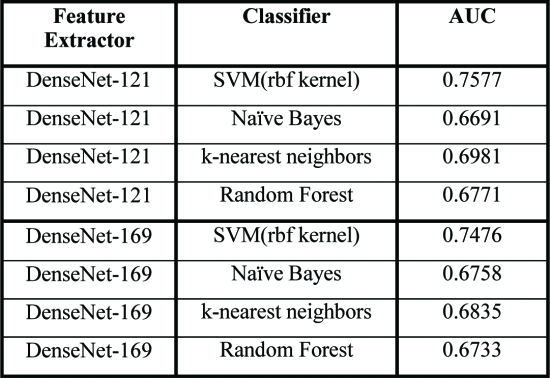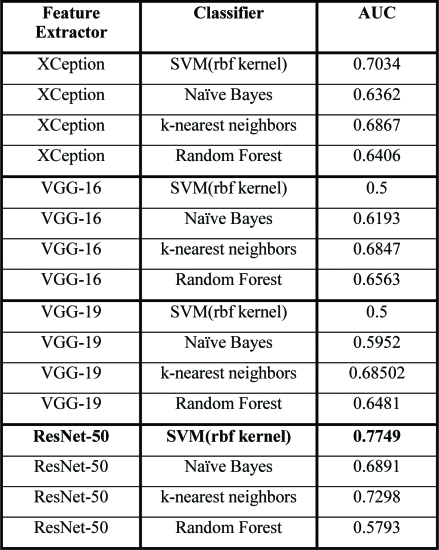

However, this study did have limitation. Despite a higher performance metrix there were challenges including class imbalance, computational costs and a reliance on a large labelled dataset.

Section 2.3 Why does classifying outperform manual feature extraction

Models trained on raw x-ray images using CNN-based learning outperforms manual feature extraction because CNN's learn image features directly from pixel intensity values, rather than relying on measurements defined by humans. This allows the model to capture diagnostic patterns that are too suble or complex for manual analysis. As a result, CNN based approaches are able to lower the semantic gap whereas manual features is limited to what humans believe to be relevant.

One key reason for this improvment is that CNN's automatically discover features from raw pixel distrubutions. These models can detect weak texture changes, gradient that may be too subtle for humans to define. In contrast manually extracted features are restricted to predefined measurements.

Secondly, CNN-based learning removes reliance on prior assumptions about which features are most relevant. Manual feature extraction introduce human bias as it depends on domain knowledge. CNNs instead learn which features are useful directly from data, and uses information that humans may overlook

Finally, the factor with the biggest impact is largely driven by hierarchial feature learning. CNNs learn features at multiple levels of layers, starting with simple patterns such as edges and lines and progressing to more complex layers like patterns and shapes and finally disease related structures in deeper layers.

Section 2.4 Judgement

Althought Classifying raw images is likely to outperform manual features in many cases, its effectiveness depends on the dataset and task. In the scenario discussed above, the improved performance was largely due to the availability of a large, well-prepared dataset, where images had been preproccessed, consistently sizes and accurately labelled.

However, this is not always the case. When datasets are smaller or imbalanced, raw image classification would be more likely to suffer from limitationssuch as not trained on rarer diseases and generalisation. In these situations, class imbalance would become a significant issue, and the lack of interpretability would negatively affect the trust in the models predictions

Therefore a balanced approach would be ideal where CNN can support diagnosis by highlighting potential abnormalities, but they should not fully automate the decision making process.Human oversight remains nessasry, particularly in rare cases where manual assessment is vital

Overral, evidence has suggested that raw images base learning can outperform manual measurements in many tasks, provided sufficient data and suitable model methodology

## Section 3: Save on staff time?

Is it possible to save staff time by classifying raw images?

**Training Time**
CNN require a significant amount of effort to initially train from scratch and requires a lot of computational power. However, in practise this is rarely necessary. Instead, pretrained models are commonly used and fine-tuned for medical imaging tasks. As Khan and Aleem (2025) noted "It uses models learnt on other available benchmarks such as ResNet, DenseNet and VGG which are first trained on large databases as ImageNet, and then fine-tuned for a given task"

This approach significantly reduced training time and removes the need for staff to design or train CNN models from scratch. Fine tuning is still required, although this is infrequent.

**Prediction Time**

Once trained, Prediction time is negliagble. A trained CNN can classify X-ray images in milliseconds, allowing a large range of information to quickly be processed. While other configurations can be adjusted such as batch size,which when enabled allows a set amount of images but comes at a cost of making a big in terms of memory utilisation and thereby computational time. Prediction still remains faster and enables a faster workflow and reducing time spent extracting individual xrays.

**Data collection & Labels**

Data would be required regardless of the modelling approach. However, classifying raw image does not necessarily require newly collected data which is time consuming and expensive. instead pre-existing clincal x-rays datasets is sufficient. New data is mainly required when dealing with rare diseases or poor quality datasets

Labelled data is required for CNN based classification, but this does not always need to be done manually produced. In large x-ray datasets, labels are already derived from existing clinical reports and radiological reports. As stated in the reference "These labels were concluded through Natural Language Processing (NLP) by text-mining disease-classification"
Using NLP saves time although are not always accurate and may introduce some label noise, which can affect model performance

**Staff Training**

Clinical Staff do not need to operate or understand the model. Their involvement is mainly required for validating the model, particularly in rare and complex case. This reduces the need for training and allows for clinical oversight

Additionally, this approach saves non clinical staff time of extracting relevant features from xrays

**Maintainance**

Models may still require retraining or updates to the dataset. However this still saves staff hours of manually extracting features from patients x-rays




In [ ]:
# and perhaps using code cells / experiments as well

# ...

...

## Section 4: There are no downsides

**4.1: CNN's are not perfect**

Unlike humans, CNN based models lack clinical judgement and can make mistake. Errors would commonly occur due to poor image quality, bias or incomplete training data and the underrepresentation of rare diseases leading to class imbalance and poor prediction
These errors could result in false positive, where patients receive unnecessary treatment or false positivies,where serious conditions are missed.

Another limitations of CNN's is their lack of interpretability. Unlike manual feature based approaches, CNNs do not provide clear explanations for their prediction. This is referred the "Black Box" problem. While techniques like Grad-Cams can highlights image regions showing the heatmap of a decision but it does explain the reasoning behind the prediction, which can leads to distrust and limit use cases

4.1: Ethical and Consent

Ethical concerns arise around the use of patient data for training and deploying machine learning models. Patients must provide informed consent when their medical images are used, particularly in clinical settings. Although public datasets used in the literature typically include consent, these issues become more complex if models are deployed in real-world healthcare environments.

4.2: Patient Anonymity

Medical images are highly sensitive, and there is a risk of data breaches or patient re-identification, even after anonymisation. While removing personal identifiers during preprocessing reduces this risk, it cannot be entirely eliminated

4.3: Environmental and Computational Cost

Training deep CNNs on large datasets requires high computational resources and energy consumption, contributing to significant carbon footprint. This becomes increasingly problematic if models are frequently retrained or deployed at scale.

4.4: Impact on Non-Clinical Staff Roles

With automating the process of classifying raw image it is very likely to save staff time by reducing need to extract feature roles , however while efficiency improves, this raises concerns around potential job displacement

You will need to cite and reference all other sources of information, ideas or materials as part of this work, and so you will have citations within the body of the notebook, and a final "References" text cell at the end. One has been left in below as a reminder. It includes a link to the MMU library guidance for using Cite Them Right Harvard.

CNN Pneumonia data set


In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = paultimothymooney_chest_xray_pneumonia_path

if 'chest_xray' in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, 'chest_xray')

train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')
test_dir = os.path.join(dataset_path, 'test')
# --------------------------------------------

img_size = 150
batch_size = 30

train_datagen = ImageDataGenerator(rescale = 1/255.,
                                   featurewise_std_normalization=True,
                                   brightness_range=[0.6,1.2])

val_datagen = ImageDataGenerator(rescale = 1/255.)
test_datagen = ImageDataGenerator(rescale = 1/255.)


train_generator = train_datagen.flow_from_directory(train_dir,
                                                   target_size = (img_size, img_size),
                                                   batch_size = batch_size,
                                                   shuffle=True,
                                                   class_mode='binary')

val_generator = val_datagen.flow_from_directory(test_dir,
                                                   target_size = (img_size, img_size),
                                                   batch_size = batch_size,
                                                   shuffle=False,
                                                   class_mode='binary')

test_generator = test_datagen.flow_from_directory(test_dir,
                                                   target_size = (img_size, img_size),
                                                   batch_size = batch_size,
                                                   shuffle=False,
                                                   class_mode='binary')

In [ ]:
# Visualising Augmented Training Data
labels = ['normal', 'pneumonia']


samples = train_generator.__next__()
images = samples[0]
target = samples[1]

plt.figure(figsize=(20,20))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.imshow(images[i])
    plt.title(f"Class: {labels[int(target[i])]}")
    plt.axis('off')
plt.show()

In [ ]:
len(os.listdir("../input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA"))

Data Visualisation

In [ ]:
print("Train set counts:")
print("========================================")

p_train_path = os.path.join(train_dir, 'PNEUMONIA')
n_train_path = os.path.join(train_dir, 'NORMAL')

# Check counts
print(f"PNEUMONIA={len(os.listdir(p_train_path))}")
print(f"NORMAL={len(os.listdir(n_train_path))}")

# --- VISUALIZE RAW IMAGES
pneumonia_files = os.listdir(p_train_path)

plt.figure(figsize=(20, 10))
plt.suptitle("Raw Pneumonia Samples", fontsize=16)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img_path = os.path.join(p_train_path, pneumonia_files[i])
    img = plt.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
normal_files = os.listdir(n_train_path)

plt.figure(figsize=(20, 10))
plt.suptitle("Raw Normal Samples", fontsize=16)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img_path = os.path.join(n_train_path, normal_files[i])
    img = plt.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

# --- PIXEL STATISTICS
sample_path = os.path.join(n_train_path, normal_files[0])
sample_img = plt.imread(sample_path)

plt.figure(figsize=(6,6))
plt.imshow(sample_img, cmap='gray')
plt.colorbar()
plt.title('Pixel Intensity Heatmap')
plt.show()

print(f"IMAGE DIMENSIONS: {sample_img.shape[0]} x {sample_img.shape[1]} pixels.")
print(f"MAX PIXEL VALUE: {sample_img.max():.4f}")
print(f"MIN PIXEL VALUE: {sample_img.min():.4f}")
print("Analysis: This confirms the high dimensionality of the raw data compared to Task 1.")

# Investigate pixel value distribution

In [ ]:
sns.distplot(sample_img.ravel(),
            label=f"Pixel Mean {np.mean(sample_img):.4f} & Standard Deviation {np.std(sample_img):.4f}", kde=False)
plt.legend(loc='upper center')
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixels in Image')

# 2. Image Preprocessing
Before training, we'll first modify your images to be better suited for training a convolutional neural network. For this task we'll use the Keras ImageDataGenerator function to perform data preprocessing and data augmentation.

This class also provides support for basic data augmentation such as random horizontal flipping of images.
We also use the generator to transform the values in each batch so that their mean is 0 and their standard deviation is 1 (this will faciliate model training by standardizing the input distribution).
The generator also converts our single channel X-ray images (gray-scale) to a three-channel format by repeating the values in the image across all channels (we will want this because the pre-trained model that we'll use requires three-channel inputs).

In [ ]:
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup Paths
base_path = paultimothymooney_chest_xray_pneumonia_path

if 'chest_xray' in os.listdir(base_path):
    base_path = os.path.join(base_path, 'chest_xray')

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
val_dir = os.path.join(base_path, 'val')

print(f"Dataset found at: {base_path}")

# Setting up generators
img_size = 150
batch_size = 30

# Training Generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.6, 1.2],
    zoom_range=0.2,
    horizontal_flip=True
)

# Test/Validation Generators
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Loading Imagines
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

print("Loading Validation Data...")
val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print("Loading Test Data...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Building a CNN model

## Impact of imbalance data on loss function

Loss Function:
$$\mathcal{L}_{cross-entropy}(x_i) = -(y_i \log(f(x_i)) + (1-y_i) \log(1-f(x_i))),$$

We can rewrite the the overall average cross-entropy loss over the entire training set `D` of size `N` as follows:
$$\mathcal{L}_{cross-entropy}(\mathcal{D}) = - \frac{1}{N}\big( \sum_{\text{positive examples}} \log (f(x_i)) + \sum_{\text{negative examples}} \log(1-f(x_i)) \big).$$



When we have an imbalance data, using a normal loss function will result a model that bias toward the dominating class. One solution is to use a weighted loss function. Using weighted loss function will balance the contribution in the loss function.

$$\mathcal{L}_{cross-entropy}^{w}(x) = - (w_{p} y \log(f(x)) + w_{n}(1-y) \log( 1 - f(x) ) ).$$

In [ ]:
# Class weights
num_pneumonia = 3875
num_normal = 1341

weight_for_0 = num_pneumonia / (num_normal + num_pneumonia)
weight_for_1 = num_normal / (num_normal + num_pneumonia)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for class 0: {weight_for_0:.2f}")
print(f"Weight for class 1: {weight_for_1:.2f}")

In [ ]:
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint


model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(150, 150, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(150, 150, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
r = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight,
    steps_per_epoch=100,
    validation_steps=25,
)

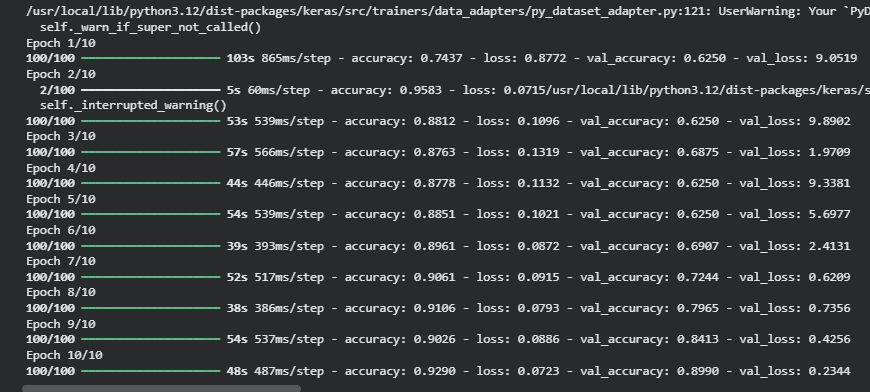

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [ ]:
evaluation = model.evaluate(test_generator)
print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

evaluation = model.evaluate(train_generator)
print(f"Train Accuracy: {evaluation[1] * 100:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(test)

print(confusion_matrix(test.classes, pred > 0.5))
pd.DataFrame(classification_report(test.classes, pred > 0.5, output_dict=True))

In [ ]:
print(confusion_matrix(test.classes, pred > 0.7))
pd.DataFrame(classification_report(test.classes, pred > 0.7, output_dict=True))

# Evaluation

In [ ]:
predicted_vals = model.predict(test, steps=len(test))

In [ ]:
print(confusion_matrix(test.classes, predicted_vals > 0.5))
pd.DataFrame(classification_report(test.classes, predicted_vals > 0.5, output_dict=True))

# Conclusion

Across this investigation a variety of models were evaluated such including classical models such as random forest to artificual neural networks to a range of ensembles, all evaluated across a consistent recipe. This included additional improvements such as data cleaning, stratified sampling, k fold validation and performance metrics such as accuracy and f1 to account for class imbalance.

These measures amongst others contributed to a higher performance with logistic regression identified as the strongest performance with a f1 metric of 0.6484 when combined with hyperparameter max_iter=5 and penalty=l1. This demonstrates that manually extracted features can still be effective when used with strong classifiers. This approach does still have its limitations especially by having a strong reliance on the inputted measurements.

Ensembles were also utilised with the Voting Ensemble performing the highest, which combined the best 3 models Artificial Neural Network, Logistic Regression and KNN along with its hyperparameters. Although it reached a respectable F1 Macro of 0.6374 it did not out perform our best individual model.

Overrall, Logistic Regression with L1 regularisation and max_iter=5 is recommended as the most suitable model for this dataset. Its performance is strong, efficient and does not require a large dataset. Its future performance was estimated by the use of Stratified K-Fold cross validation which averages the performance and estimates how it will perform on new unseen data. This is possible as it evaluates it across multiple train-test splits.

The colleagues claim that classifying raw x-ray images directly is a better approach than the manually extracted features, has higher performance, saves time and there are no downsides. Overrall, the evidence suggests that the collegues claim is correct but in certain conditions.

Literature and the CNN model tested in this analysis shows that CNN based models trained on raw x-ray images can outperform classical models using manually extracted features. This is mainly because deep learning models can learn patterns that are difficult to define manually. These results exceed the results seen in task 1 where the highest performance was observed by Logistic Regression

However, the claim that this can be achieved without downsides is not justified. The literature highlights significant risks, including sensitivity to dataset shift,
Futhermore in practice, while raw image classification also saves staff time during prediction, it does introduce new challenges around ethics, training, maintance and trust in the new system. The main challenge being when the model encounters rare diseases and domain knowledge is needed.

On balance, while the colleague is correct that raw X-ray classification can achieve higher performance under ideal conditions and may reduce manual measurement workload, the approach introduces non-trivial risks related to robustness, transparency, and clinical governance. Therefore, the claim should not be accepted in its absolute form.

Overall, a fully automated replacement of the manual measurement pipeline is not advisable. A more appropriate direction is a hybrid strategy, in which CNN-based image models are pursued as decision-support tools alongside interpretable feature-based systems, with human clinical oversight retained. This balances the performance advantages of deep learning with the reliability, explainability, and safety considerations demonstrated by the manual feature approach evaluated in this coursework.

# References

Varshni, D., Thakral, K., Agarwal, L., Nijhawan, R. and Mittal, A. (2019) ‘Pneumonia detection using CNN based feature extraction’, in Proceedings of the 2019 IEEE International Conference on Electrical, Computer and Communication Technologies (ICECCT), Coimbatore, India, 20–22 February. Piscataway, NJ: IEEE, pp. 1–7. doi:10.1109/ICECCT.2019.8869364.


Beghoura, I., Benssalah, M. and Sbargoud, F. (2024) ‘Feature extraction for pneumonia diagnosis using conventional methods’, in Proceedings of the 1st International Conference on Electrical, Computer, Telecommunication and Energy Technologies (ECTE-Tech), Oum El Bouaghi, Algeria. Piscataway, NJ: IEEE, pp. 1–6. doi:10.1109/ECTE-Tech62477.2024.10851007.

Khan, K. and Aleem, A. (2025) ‘Lung disease detection using CNNs and transfer learning on medical imaging’, in Proceedings of the 3rd International Conference on Communication, Security, and Artificial Intelligence (ICCSAI), Greater Noida, India. Piscataway, NJ: IEEE, pp. 1196–1203. doi:10.1109/ICCSAI64074.2025.11063806.


# Submission

Once you're ready to submit, you need to compress the whole of your 1CWK100 folder as a .zip file (no other compression formats), and upload it to Moodle. There are several ways to do this, but the instructions below offer a simple step-by-step guide:

*    **Make sure the output from any code cells you have added is showing (you can select 'Runtime' -> 'Run all' if you need to)**
*    Save your notebook (select 'File' -> 'Save')
*    Find your /1CWK100/ folder via the Google Drive web interface ([https://drive.google.com/](https://https://drive.google.com/))
*    Right-click on the /1CWK100/ folder, and select 'Download'. This will cause the folder to be compressed into a .zip file and then downloaded to your local machine.
*    Upload the resulting .zip file to the 1CWK100 submission point on Moodle.
*    (If the .zip is too large for Moodle, upload it to your University OneDrive instead, and upload a link to that copy on Moodle)

**We recommend testing these steps, and asking any questions you might have, well before the final deadline.**